In [4]:
import arviz as az
import numpy as np
from scipy.stats import wishart

# Set random seed for reproducibility (same seed of Mattia's 250D notebook)
rng = np.random.default_rng(12345)

In [5]:
# body of the foor loop in the algorithm 3
def NUTS_one_step(L: Callable,
                  theta_0: jnp.ndarray,
                  epsilon: float,
                  key: jnp.ndarray,
                  j_max: int = 10):

    # 1. Sample momentum
    key, sub_r = jrnd.split(key)
    r_0 = jrnd.normal(sub_r, shape=theta_0.shape)

    # 2. Slice variable
    log_joint_0 = log_p(L, theta_0, r_0)
    key, sub_u = jrnd.split(key)
    u = jnp.exp(log_joint_0) * jrnd.uniform(sub_u)

    # 3. Initialize tree
    theta_minus = theta_0
    theta_plus  = theta_0
    r_minus     = r_0
    r_plus      = r_0
    theta_prime = theta_0
    n_prime     = jnp.array(1, dtype=jnp.int32)
    s_prime     = jnp.array(1, dtype=jnp.int32)
    alpha_sum   = jnp.array(0.0)
    n_alpha     = jnp.array(0, dtype=jnp.int32)

    # depth of the tree
    j = 0 

    # 4. Doubling
    while (s_prime == 1) & (j < j_max):

        # Choose a direction
        key, sub_v = jrnd.split(key)
        v_j = jnp.where(jrnd.uniform(sub_v) < 0.5, -1, 1)

        if v_j == -1:
            root = Root(theta_minus, r_minus, u, v_j, j, epsilon, theta_0, r_0)
        else:
            root = Root(theta_plus,  r_plus,  u, v_j, j, epsilon, theta_0, r_0)

        # Call the BuildTree function
        tree, key = BuildTree(L, root, key)

        if v_j == -1:
            theta_minus, r_minus = tree.theta_minus, tree.r_minus
        else:
            theta_plus,  r_plus  = tree.theta_plus,  tree.r_plus

        key, sub = jrnd.split(key)
        total_n = n_prime + tree.n_prime
        p = jnp.where(total_n > 0, tree.n_prime / total_n, 0.5)
        choose = jrnd.bernoulli(sub, p)
        theta_prime = jnp.where(choose, tree.theta_prime, theta_prime)

        n_prime   = n_prime + tree.n_prime
        s_prime   = s_prime * tree.s_prime * stop_criterion(
            theta_minus, theta_plus, r_minus, r_plus
        )
        alpha_sum = alpha_sum + tree.alpha_prime
        n_alpha   = n_alpha + tree.n_a_prime

        j += 1

    accept_rate = alpha_sum / jnp.maximum(1, n_alpha)
    return theta_prime, accept_rate, key


In [6]:
def NUTS_sampler(L: Callable,
                 theta_init: jnp.ndarray,
                 n_samples: int,
                 key: jnp.ndarray,
                 j_max: int = 10):

    epsilon = float(FindReasonableEpsilon(L, theta_init, key))

    thetas = []
    accs = []

    theta = theta_init

    for i in range(n_samples):
        theta, acc, key = NUTS_one_step(L, theta, epsilon, key, j_max=j_max)
        thetas.append(np.array(theta))
        accs.append(float(acc))

    return np.stack(thetas), np.array(accs), epsilon


In [7]:
# Define the pseudo log-potential
# Gaussian log-density
D = 10
df = D
A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)

@jax.jit
def L(theta: jnp.ndarray, precision_mat = A) -> jnp.float32:
    assert theta.ndim == 1
    return -0.5 * jnp.vdot(theta, precision_mat @ theta) 

In [8]:
dim = D
theta0 = jnp.zeros(dim)
key = jrnd.PRNGKey(0)

samples, accs, eps = NUTS_sampler(L, theta0, n_samples=1000, key=key)

print("epsilon:", eps)
print("mean:", samples.mean(axis=0))
theta_mean = samples.mean(axis=0)
print("cov:\n", np.cov(samples.T))
cov_mat = np.cov(samples.T)
print("mean accept rate:", accs.mean())

epsilon: 0.125
mean: [-0.42082056  0.06160904  0.06352863  0.30412665  0.45419908  0.68885577
 -0.79164636  0.0697044  -0.13829066  0.30214015]
cov:
 [[ 26.87608262   2.78884255  -5.07208739  -2.95279889 -11.76361735
  -22.67855112  18.26065997  -3.84395129  -2.29993451 -14.05602954]
 [  2.78884255   2.25572278   1.03672189   2.1898709    0.86761842
    2.21614359  -4.03682727   2.20237305  -3.77251003  -1.33989672]
 [ -5.07208739   1.03672189   3.50882043   2.04679927   2.85974111
    7.72439614  -6.84916563   4.53993124  -3.00615413   1.50458043]
 [ -2.95279889   2.1898709    2.04679927   4.4855191    5.1384645
    9.26250603 -11.28406615   3.30768983  -4.35678416   2.13725821]
 [-11.76361735   0.86761842   2.85974111   5.1384645    9.18125456
   16.02717622 -16.7860379    3.3284115   -2.64462598   7.31976091]
 [-22.67855112   2.21614359   7.72439614   9.26250603  16.02717622
   31.48015351 -31.31652805   9.68496398  -6.967368    11.96215539]
 [ 18.26065997  -4.03682727  -6.84916563 

/home/pira/miniconda3/envs/inf/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n7'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>,
        <Axes: xlabel='t

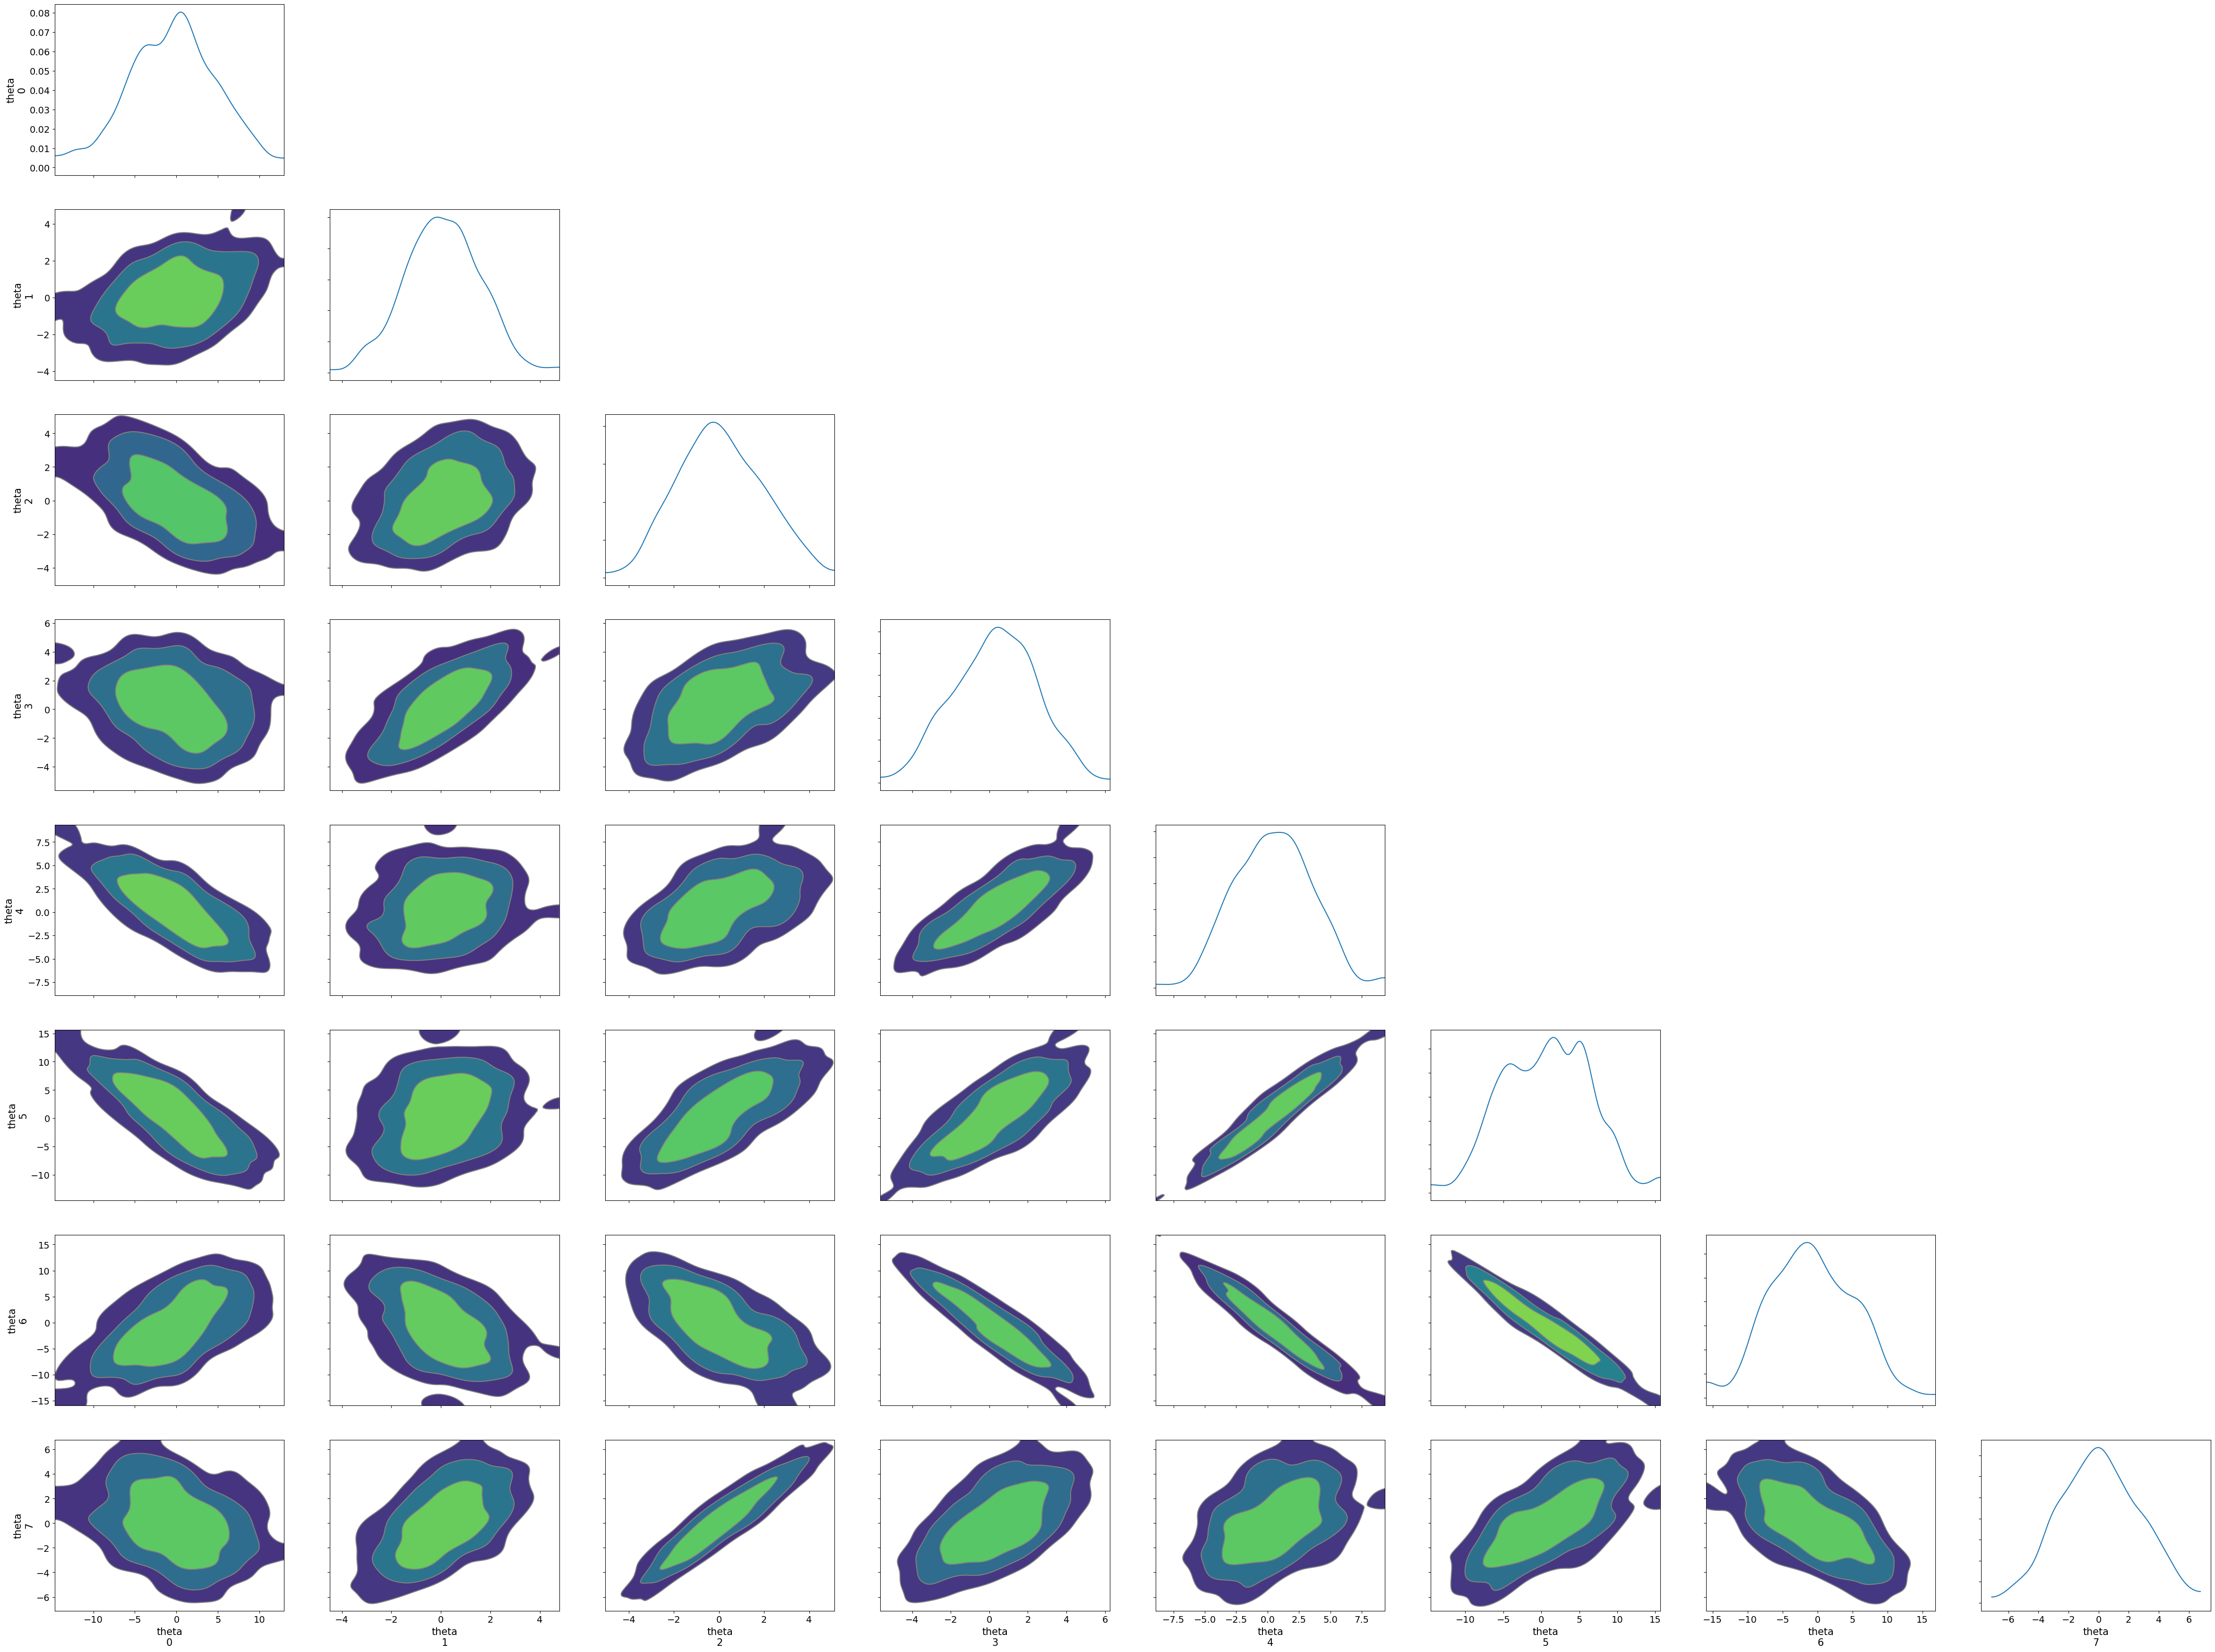

In [9]:
data_sample = samples[None, :, :]  

idata = az.from_dict(
    posterior={"theta": data_sample},
    coords={"theta_dim": np.arange(data_sample.shape[2])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

In [10]:
var_k = [ cov_mat[i,i] for i in range(D) ]
var_k

[np.float64(26.876082615061147),
 np.float64(2.2557227815828895),
 np.float64(3.5088204270480823),
 np.float64(4.485519100590009),
 np.float64(9.181254558568273),
 np.float64(31.480153508373775),
 np.float64(34.1827965325916),
 np.float64(6.877794837796301),
 np.float64(7.359941596887335),
 np.float64(9.276009162449082)]

In [11]:
theta_mean

array([-0.42082056,  0.06160904,  0.06352863,  0.30412665,  0.45419908,
        0.68885577, -0.79164636,  0.0697044 , -0.13829066,  0.30214015],
      dtype=float32)

In [12]:
import matplotlib.pyplot as plt

In [32]:
samples.T[0] # select the sampled values fot the first variable

array([-2.38164878e+00,  2.12422061e+00,  1.76210308e+00,  9.48694706e-01,
        1.33592379e+00, -1.83841616e-01,  3.18557930e+00,  3.34684896e+00,
       -3.31401730e+00, -2.76553369e+00, -1.93505275e+00, -1.40072381e+00,
       -7.10545540e-01, -8.83868158e-01,  6.03088200e-01, -1.07438672e+00,
        3.69002670e-02, -2.49028921e+00, -3.32947826e+00, -3.96929622e+00,
       -3.51134515e+00,  5.80741978e+00,  6.08886003e+00, -1.44526482e+01,
       -1.46477623e+01, -1.43402424e+01, -1.37568541e+01, -1.23089657e+01,
       -1.32001896e+01, -1.22286253e+01, -1.28483315e+01, -1.10906038e+01,
       -1.03050070e+01, -7.08662391e-01, -1.44662440e-01, -2.93673825e+00,
       -2.74703145e+00, -3.31357265e+00, -3.27082324e+00,  5.94458294e+00,
        7.90108156e+00,  7.90108156e+00,  8.17354107e+00,  6.87418556e+00,
       -1.25592461e+01, -1.26909056e+01, -1.19523802e+01, -1.17868061e+01,
        3.63724613e+00,  2.81785560e+00, -1.07428586e+00, -2.99610496e-02,
       -1.00480950e+00, -

In [56]:
samples.T[0]

array([-2.38164878e+00,  2.12422061e+00,  1.76210308e+00,  9.48694706e-01,
        1.33592379e+00, -1.83841616e-01,  3.18557930e+00,  3.34684896e+00,
       -3.31401730e+00, -2.76553369e+00, -1.93505275e+00, -1.40072381e+00,
       -7.10545540e-01, -8.83868158e-01,  6.03088200e-01, -1.07438672e+00,
        3.69002670e-02, -2.49028921e+00, -3.32947826e+00, -3.96929622e+00,
       -3.51134515e+00,  5.80741978e+00,  6.08886003e+00, -1.44526482e+01,
       -1.46477623e+01, -1.43402424e+01, -1.37568541e+01, -1.23089657e+01,
       -1.32001896e+01, -1.22286253e+01, -1.28483315e+01, -1.10906038e+01,
       -1.03050070e+01, -7.08662391e-01, -1.44662440e-01, -2.93673825e+00,
       -2.74703145e+00, -3.31357265e+00, -3.27082324e+00,  5.94458294e+00,
        7.90108156e+00,  7.90108156e+00,  8.17354107e+00,  6.87418556e+00,
       -1.25592461e+01, -1.26909056e+01, -1.19523802e+01, -1.17868061e+01,
        3.63724613e+00,  2.81785560e+00, -1.07428586e+00, -2.99610496e-02,
       -1.00480950e+00, -

In [65]:
th_var_k = [ A[i,i] for i in range(D) ]
th_var_k

[np.float64(5.317389514687243),
 np.float64(17.158484038801728),
 np.float64(9.963343436281699),
 np.float64(7.994883177741448),
 np.float64(13.521272174557707),
 np.float64(10.445940874900273),
 np.float64(6.913799365276526),
 np.float64(6.104938256871378),
 np.float64(15.963432619092039),
 np.float64(4.472008171971871)]

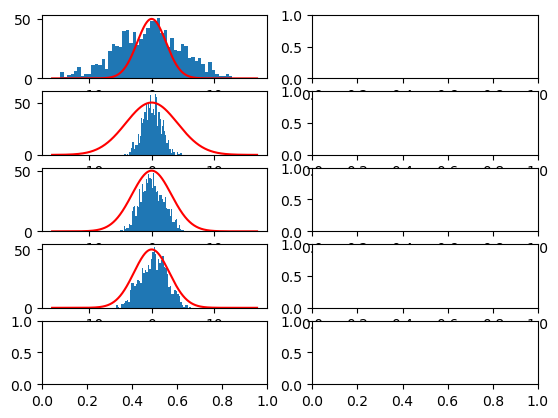

In [78]:
x = np.linspace(samples.min(), samples.max(), 1000)  

#plt.figure(figsize=(5, 2.7), layout='constrained')

fig, axs = plt.subplots(5, 2)

for j in range(1):
    for i in range(4):
        if j==0:
            # The theorical posterior from which we want to sample data is a gaussian with mean 0 and var_i = A[i,i]
            axs[i,j].plot(x, 50*np.exp(-(0.5)*(x**2)/th_var_k[i]), label='gaussian pdf', color='red')  
            axs[i,j].hist(samples.T[i], bins=50, label='sampled data')
        else:
            axs[i,j].plot(x, 50*np.exp(-(0.5)*(x**2)/th_var_k[i+5]), label='gaussian pdf', color='red')  
            axs[i,j].hist(samples.T[i+5], bins=50, label='sampled data')
           
